## Linear Regression Seaborn Practice Dataset 1


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [4]:
# we will be using mpg dataset

df = sns.load_dataset('mpg')
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [8]:
print(df.shape)
print('\n',df.columns,'\n')
print(df.info())

(398, 9)

 Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'origin', 'name'],
      dtype='object') 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB
None


## Data cleaning

In [9]:
#check for null
df.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,6
weight,0
acceleration,0
model_year,0
origin,0
name,0


In [10]:
df.dropna(inplace = True)
df.isnull().sum().sum()

np.int64(0)

In [12]:
#check for duplicates
df.duplicated().sum()

np.int64(0)

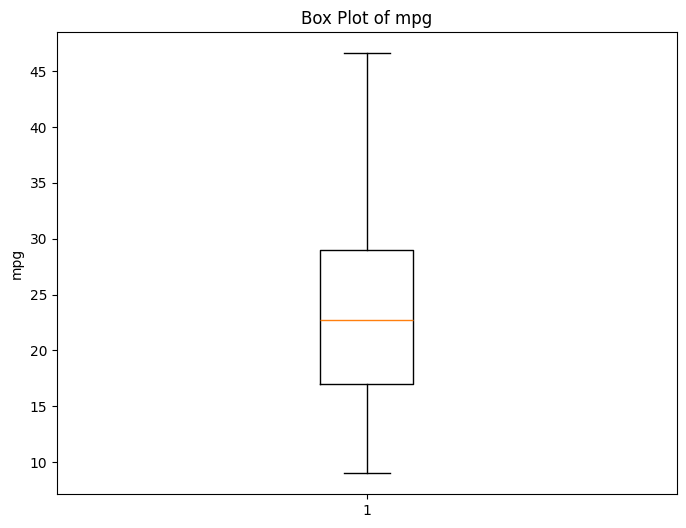

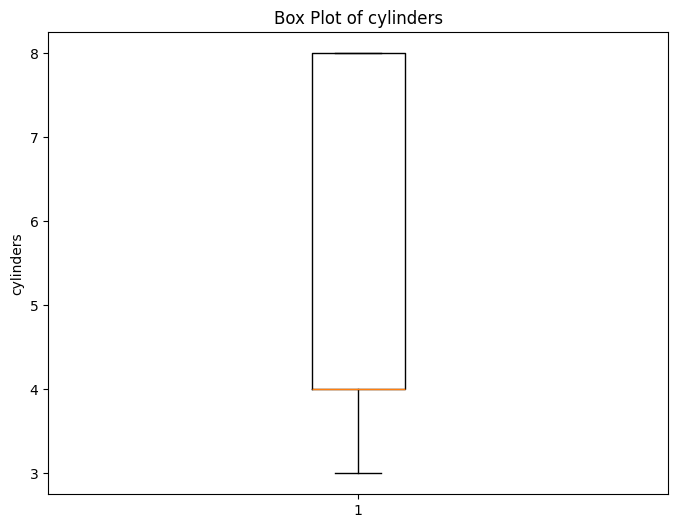

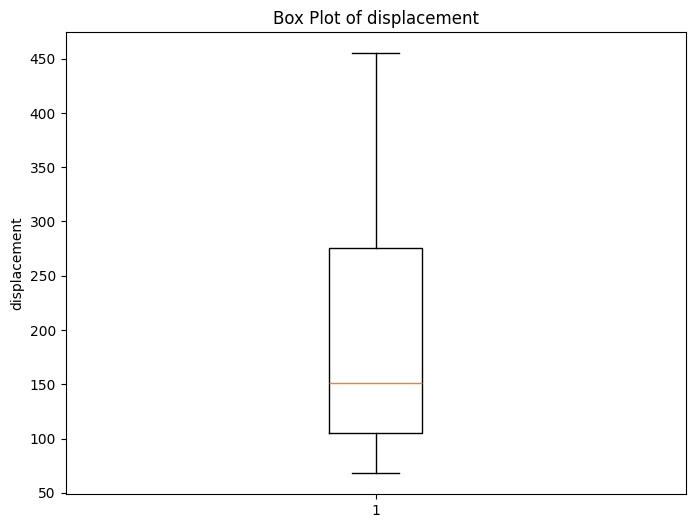

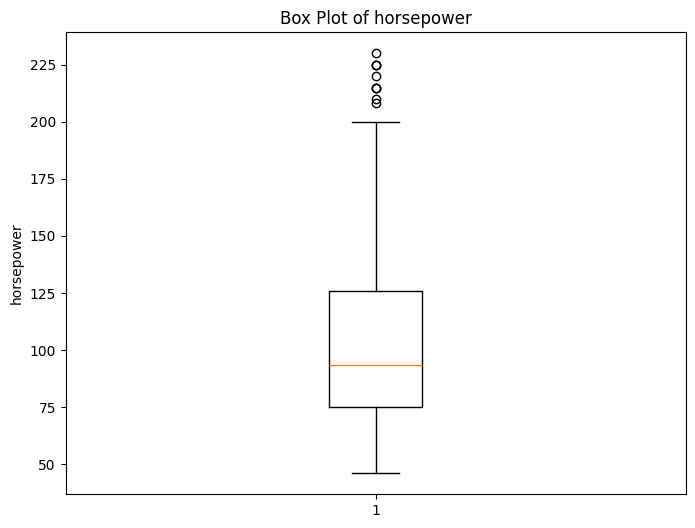

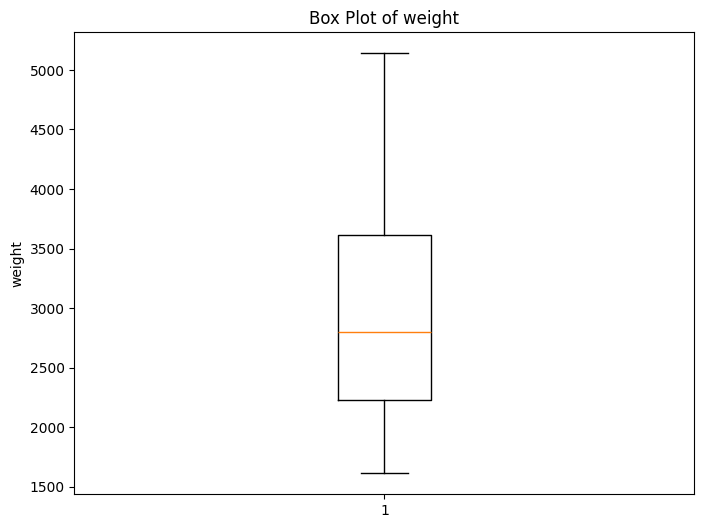

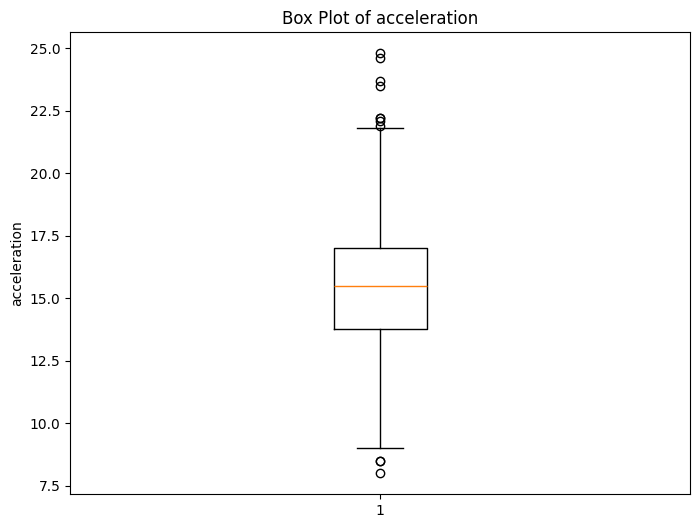

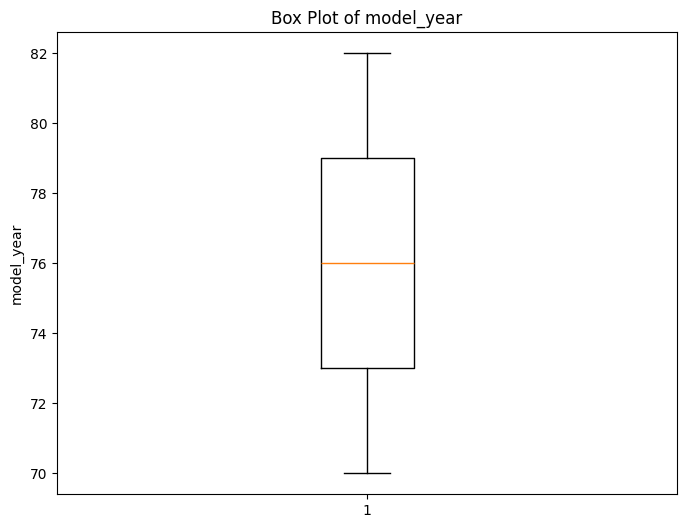

In [16]:
for col in df.columns:
  if df[col].dtype != 'object':
    plt.figure(figsize=(8, 6))
    plt.boxplot(df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    plt.show()

In [18]:
# VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor


# drop our target column and dtype = object columns
X = df.drop(columns=['horsepower', 'origin', 'name'])
Y = df['horsepower']

vif = pd.DataFrame()
vif['features'] = X.columns
vif['VIF Values'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
display(vif)

,features,VIF Values
0,mpg,51.042867
1,cylinders,116.691251
2,displacement,82.899819
3,weight,152.068737
4,acceleration,49.605121
5,model_year,247.563459


In [22]:
X = df.drop(columns=['horsepower', 'origin', 'name', 'model_year'])

vif = pd.DataFrame()
vif['features'] = X.columns
vif['VIF Values'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
display(vif)

,features,VIF Values
0,mpg,16.451003
1,cylinders,106.735054
2,displacement,78.408048
3,weight,108.565453
4,acceleration,42.714105


In [23]:
X = df.drop(columns=['horsepower', 'origin', 'name', 'model_year', 'cylinders'])

vif = pd.DataFrame()
vif['features'] = X.columns
vif['VIF Values'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
display(vif)

,features,VIF Values
0,mpg,14.998428
1,displacement,44.616655
2,weight,102.399843
3,acceleration,41.259815


In [25]:
X = df.drop(columns=['horsepower', 'origin', 'name', 'model_year', 'cylinders', 'weight'])

vif = pd.DataFrame()
vif['features'] = X.columns
vif['VIF Values'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
display(vif)

,features,VIF Values
0,mpg,14.955866
1,displacement,3.827515
2,acceleration,22.541127


In [26]:
X = df.drop(columns=['horsepower', 'origin', 'name', 'model_year', 'cylinders', 'weight', 'acceleration'])

vif = pd.DataFrame()
vif['features'] = X.columns
vif['VIF Values'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
display(vif)

,features,VIF Values
0,mpg,2.04919
1,displacement,2.04919


## Model Building

In [30]:
# now split the data in train test

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2 ,random_state = 0)

print(x_train)
print(x_test)
print(y_train)
print(y_test)

      mpg  displacement
220  33.5          85.0
256  20.5         225.0
301  34.2         105.0
193  24.0         200.0
57   24.0         113.0
..    ...           ...
325  44.3          90.0
194  22.5         232.0
118  24.0         116.0
48   18.0         250.0
174  18.0         171.0

[313 rows x 2 columns]
      mpg  displacement
146  28.0          90.0
282  22.3         140.0
69   12.0         350.0
378  38.0         105.0
331  33.8          97.0
..    ...           ...
101  23.0         198.0
65   14.0         351.0
56   26.0          91.0
262  19.2         305.0
216  31.5          98.0

[79 rows x 2 columns]
220     70.0
256    100.0
301     70.0
193     81.0
57      95.0
       ...  
325     48.0
194     90.0
118     75.0
48      88.0
174     97.0
Name: horsepower, Length: 313, dtype: float64
146     75.0
282     88.0
69     160.0
378     63.0
331     67.0
       ...  
101     95.0
65     153.0
56      70.0
262    145.0
216     68.0
Name: horsepower, Length: 79, dtype: float64


In [31]:
# regression model

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print(y_pred)

[ 72.04287894  90.61442872 156.84741918  67.51187735  68.95066071
 118.23975104  63.05631295  85.60995925 108.4373722   80.85621477
  74.81716561 152.96517329  91.72033028 171.36417882 152.62008477
  71.76774051  86.02979908 146.38339204  75.95296769  88.35571717
 142.87682108 128.27310342  92.59868773  99.48139262  62.5807874
 155.12197657  91.96419641  88.19880906 117.72211826 139.97209738
  96.96798     77.12950522  85.68471055  70.76443312 116.58631618
  82.50553431  64.26618045 169.6387362  144.65794942 183.52237629
 154.25925526  57.99478598  77.38832161 140.28865715  73.09172299
 153.66961471  83.46879212 155.98469787 139.81381749 119.44756088
  80.86842148 163.27092055 146.83038884  90.87324512  68.51930006
  84.73297356 108.81098947 120.91212944  68.00235316  86.82051263
 106.71192958  75.49376417  68.75027359 175.83263581  75.40680615
 126.08845729 179.69924556  78.91337711  80.09265819  59.63464235
  65.3279171   72.50208245 138.90830306 145.08931007 105.84920827
 155.395057

In [32]:
# accuracy of model

from sklearn.metrics import r2_score
print(r2_score(y_test, y_pred))

0.8792910539282817


## Visualization

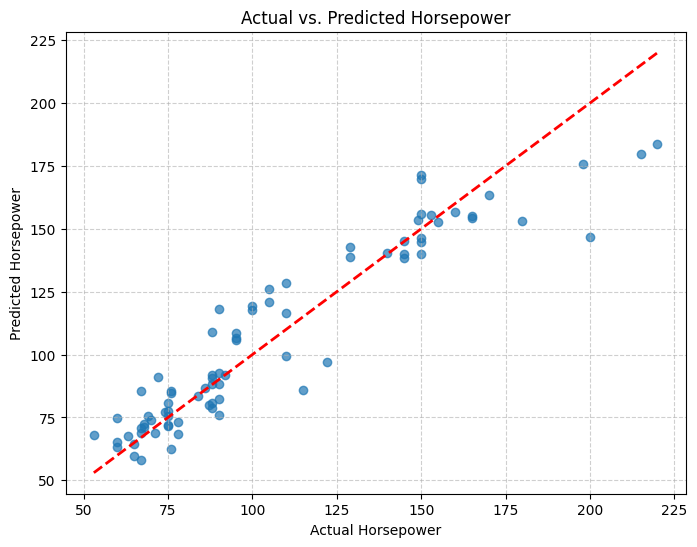

In [35]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', lw=2)
plt.xlabel("Actual Horsepower")
plt.ylabel("Predicted Horsepower")
plt.title("Actual vs. Predicted Horsepower")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

visualize the relationship between the input features and horsepower.

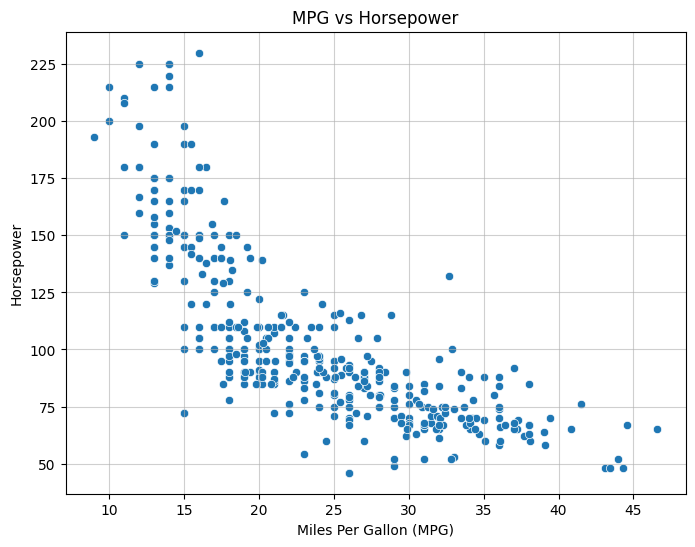

In [39]:
# Plotting mpg vs horsepower
plt.figure(figsize=(8, 6))
sns.scatterplot(x='mpg', y='horsepower', data=df)
plt.title('MPG vs Horsepower')
plt.xlabel('Miles Per Gallon (MPG)')
plt.ylabel('Horsepower')
plt.grid(True, alpha=0.6)
plt.show()

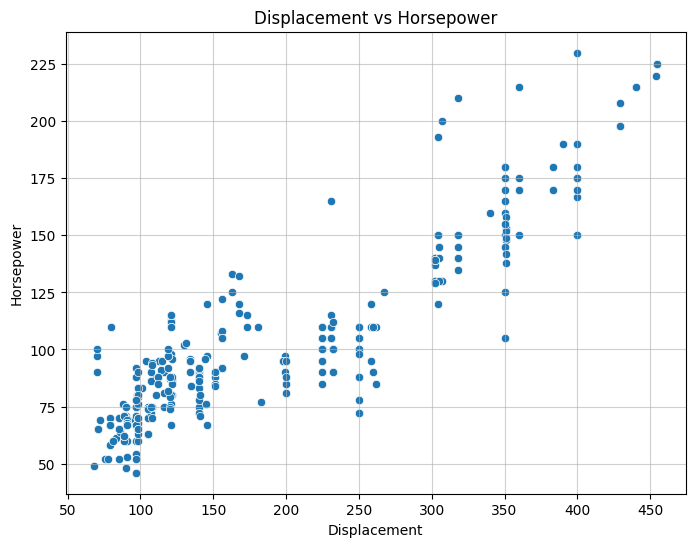

In [40]:
# Plotting displacement vs horsepower
plt.figure(figsize=(8, 6))
sns.scatterplot(x='displacement', y='horsepower', data=df)
plt.title('Displacement vs Horsepower')
plt.xlabel('Displacement')
plt.ylabel('Horsepower')
plt.grid(True, alpha=0.6)
plt.show()